# Analiza rynku nieruchomości działek budowlanych w okolicach Łomży (English version below)


## Opis problemu
Rynek nieruchomości w Polsce nieprzerwanie od kilkunastu lat jest rynkiem niesprzyjającym grupie inwestorów z niskim kapitałem, do których bardzo często zaliczają się osoby w przedziale wiekowym 20-30. Znalezienie okazji inwestycyjnej wymaga ciągłego monitoringu ogłoszeń. Głównym wyzwaniem jest brak ujednolicenia danych z różnych źródeł oraz obecność błędów w nazewnictwie lokalizacji, co utrudnia rzetelną analizę trendów cenowych i dostępności ofert.

## Opis dostępu do danych i sposób ich pozyskania
Proces pozyskiwania danych jest w pełni zautomatyzowany i opiera się na architekturze rozproszonej:
1.  VPS - Skrypt typu Scrapper uruchamiany jest cyklicznie przez harmonogram Cron. Pobrane surowe dane trafiają do plikowej bazy danych.
2.  Przetwarzanie danych przy pomocy Bielik LLM - Dane są przesyłane protokołem SCP do środowiska, gdzie model językowy Bielik-1.5B-v3 dokonuje unifikacji i czyszczenia danych.
3.  Final Processing - Przetworzone dane wracają na VPS (Processed data), skąd są pobierane do końcowej analizy w formacie Parquet.
4.  Końcowym odbiorcą danych są użytkownicy raportu Power BI, nieumieszczonego w niniejszym Notebook'u.

### Schemat procesu
![graf procesu](data/estate-scrapper-process.drawio.png)

## Opis danych i znaczenie atrybutów
Zbiór danych składa się z 757 rekordów opisanych przez 15 atrybutów:
| Atrybut          | Typ       | Znaczenie                                                                 |
|------------------|-----------|---------------------------------------------------------------------------|
| ID               | str       | Unikalny identyfikator oferty.                                            |
| DATE_ADDED       | object    | Data dodania oferty do systemu.                                           |
| LAST_UPDATED     | object    | Data ostatniej aktualizacji oferty.                                       |
| AREA_M2          | float64   | Powierzchnia nieruchomości w metrach kwadratowych.                        |
| PRICE_M2         | float64   | Cena za 1 metr kwadratowy.                                                |
| CITY             | str       | Miejscowość.            |
| LAT / LON        | float64   | Współrzędne geograficzne nieruchomości.                                   |
| PRICE            | float64   | Całkowita cena ofertowa.                                                  |
| SOURCE           | str       | Portal, z którego pochodzi ogłoszenie.                                    |
| DAY_NAME_PL      | str       | Nazwa dnia tygodnia dodania oferty.                |
| MAIN_CITY_DIST   | float64   | Odległość od głównego centrum (miasta Łomża).                                |
| SIZE_SEGMENT     | category  | Podział nieruchomości na segmenty wielkościowe.       |
| DAYS_ON_MARKET   | int64     | Liczba dni, przez które oferta jest aktywna.                              |
| MARKET_STATUS    | str       | Status oferty                                                             |

## Definicja problemu: Klasyfikacja / Regresja

Projekt de facto realizuje oba podejścia. W zbiorze danych zawarty jest atrybut ("SIZE_SEGMENT"), który zawiera informację o segmencie wielkościowym. Oprócz tego, w niniejszym notatniku zostanie przedstawione podejście do klasyfikacji atrakcyjności cenowej danej oferty oraz przy wykorzystaniu regresji, przewidywanie ceny nieruchomości na podstawie atrybutów.

## Znaczenie problemu
Analiza pozwala na udzielenie odpowiedzi na następujące pytania biznesowe:

- Kiedy przeglądać oferty? 
- Za jaką cenę w danej lokalizacji warto kupować?
- Jaka jest podaż - określenie nasycenia rynku w konkretnych segmentach wielkościowych.

# Analysis of the real estate market for building plots in the vicinity of Łomża

## Problem description

The real estate market in Poland has continuously, for over a dozen years, been unfavorable for investors with low capital, who very often include individuals aged 20–30. Finding an investment opportunity requires constant monitoring of listings. The main challenge is the lack of data standardization from different sources, as well as the presence of errors in location naming, which makes reliable analysis of price trends and offer availability difficult.

## Description of data access and acquisition method

The data acquisition process is fully automated and based on a distributed architecture:

1. VPS – A scraper script is executed cyclically via a Cron scheduler. The collected raw data is stored in a file-based database.

2. Data processing using Bielik LLM – The data is transferred via the SCP protocol to an environment where the Bielik-1.5B-v3 language model performs data unification and cleaning.

3. Final Processing – The processed data is sent back to the VPS (Processed data), from where it is retrieved for final analysis in Parquet format.

4. The final recipients of the data are users of a Power BI report, which is not included in this Notebook.

### Process diagram

![process diagram](data/estate-scrapper-process.drawio.png)

## Data description and attribute meanings

The dataset consists of 757 records described by 15 attributes:

| Attribute        | Type      | Description                                                               |
|------------------|-----------|---------------------------------------------------------------------------|
| ID               | str       | Unique identifier of the listing.                                         |
| DATE_ADDED       | object    | Date when the listing was added to the system.                            |
| LAST_UPDATED     | object    | Date of the last update of the listing.                                   |
| AREA_M2          | float64   | Property area in square meters.                                           |
| PRICE_M2         | float64   | Price per square meter.                                                   |
| CITY             | str       | Locality.                                                                 |
| LAT / LON        | float64   | Geographic coordinates of the property.                                   |
| PRICE            | float64   | Total listing price.                                                      |
| SOURCE           | str       | Portal from which the listing originates.                                 |
| DAY_NAME_PL      | str       | Name of the weekday when the listing was added.                           |
| MAIN_CITY_DIST   | float64   | Distance from the main center (city of Łomża).                            |
| SIZE_SEGMENT     | category  | Division of properties into size segments.                                |
| DAYS_ON_MARKET   | int64     | Number of days the listing is active.                                     |
| MARKET_STATUS    | str       | Listing status                                                            |

## Problem definition: Classification / Regression

The project effectively implements both approaches. The dataset contains an attribute ("SIZE_SEGMENT") that includes information about the size segment. Additionally, this notebook presents an approach to classifying the price attractiveness of a given listing, as well as using regression to predict property prices based on attributes.

## Importance of the problem

The analysis allows answering the following business questions:

- When should listings be browsed?

- At what price is it worth buying in a given location?

- What is the supply – determining market saturation in specific size segments.

# Config

In [15]:
import pandas as pd
import matplotlib as plt

# Data loading

In [2]:
data = {}

In [9]:
data["offers"] = pd.read_parquet("2026-03-29_offers_cleaned_final.parquet")

In [10]:
data["offers"].info()

<class 'pandas.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              757 non-null    str     
 1   DATE_ADDED      757 non-null    object  
 2   LAST_UPDATED    757 non-null    object  
 3   AREA_M2         653 non-null    float64 
 4   PRICE_M2        582 non-null    float64 
 5   CITY            745 non-null    str     
 6   LAT             745 non-null    float64 
 7   LON             745 non-null    float64 
 8   PRICE           583 non-null    float64 
 9   SOURCE          757 non-null    str     
 10  DAY_NAME_PL     757 non-null    str     
 11  MAIN_CITY_DIST  745 non-null    float64 
 12  SIZE_SEGMENT    653 non-null    category
 13  DAYS_ON_MARKET  757 non-null    int64   
 14  MARKET_STATUS   757 non-null    str     
dtypes: category(1), float64(6), int64(1), object(2), str(5)
memory usage: 132.7+ KB


# EDA

## When are the most offers added?

In [23]:
data["offers"]["DAY_NAME_PL"].value_counts()

DAY_NAME_PL
Sobota          141
Wtorek          120
Piątek          118
Niedziela       109
Poniedziałek     90
Czwartek         90
Środa            89
Name: count, dtype: int64

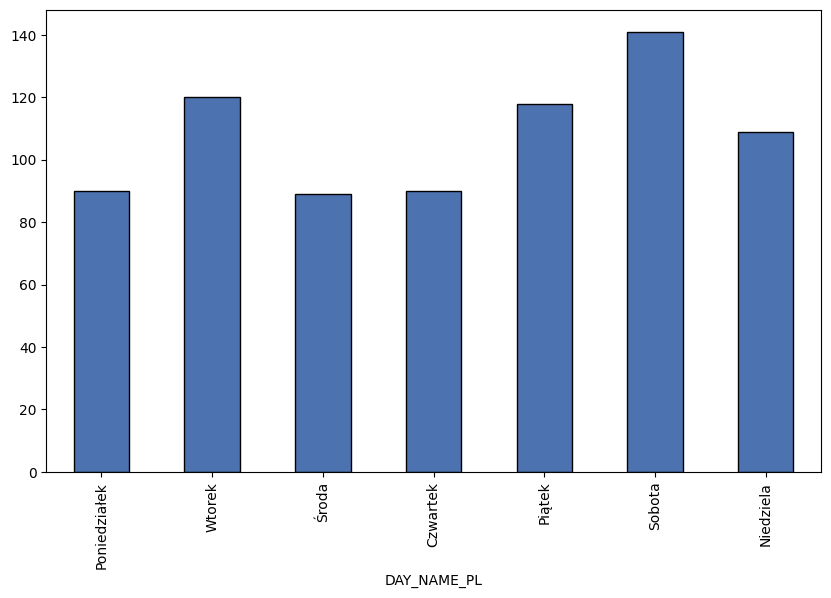

In [22]:
sort_order = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek", "Sobota", "Niedziela"]
ax = (data["offers"]["DAY_NAME_PL"]
      .value_counts()
      .reindex(sort_order)
      .plot(kind="bar", figsize=(10, 6), color="#4C72B0", edgecolor="black"))


Najwięcej ofert nieruchomości jest dodawanych w sobotę (141 ofert) oraz we wtorek (120 ofert). Wysoka aktywność w sobotę i niedzielę (łącznie 250 ofert) sugeruje, że spora część rynku to ogłoszenia prywatne, przygotowywane przez właścicieli w czasie wolnym. Z punktu widzenia inwestora, najgorętszym okresem na przeglądanie nowych ogłoszeń jest weekend oraz początek weekendu (piątek).

The highest number of real estate offers is added on Saturday (141 offers) and Tuesday (120 offers). The high activity observed on Saturday and Sunday (totaling 250 offers) suggests that a significant portion of the market consists of private listings prepared by owners during their leisure time. From an investor's perspective, the "hottest" period for browsing new listings is the weekend and its onset (Friday), allowing for a quick response and scheduling plot viewings as early as Saturday afternoon.

## What is the size segment of the offered plot?

In [27]:
data["offers"]["SIZE_SEGMENT"].value_counts()

SIZE_SEGMENT
Medium Plot              189
Small Plot               165
Large Plot               107
Hectares/Agriculture     106
Tiny/Sub-standard         53
Investment/Small Farm     33
Name: count, dtype: int64

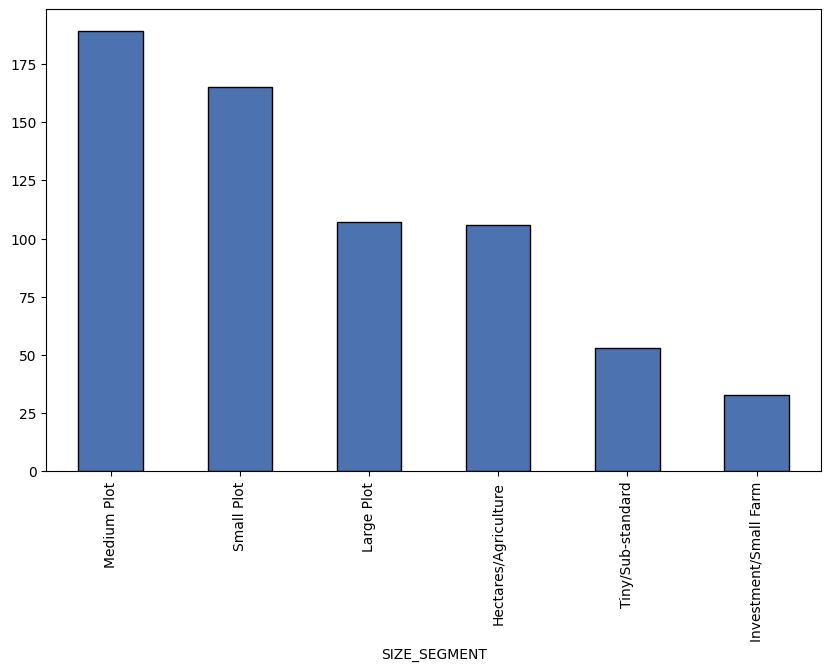

In [25]:
ax = (data["offers"]["SIZE_SEGMENT"]
      .value_counts()
      .plot(kind="bar", figsize=(10, 6), color="#4C72B0", edgecolor="black"))